In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\4_chains\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['BAYESM', 'HMC', 'NUTS']


  BAYESM   mu (4, 10000, 5, 4)
  HMC      mu (4, 10000, 5, 4)
  NUTS     mu (4, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt1       [-3.78, +6.51]
  Alt2       [-3.63, +11.59]
  Alt3       [-2.84, +9.12]
  Price      [-7.32, +2.08]


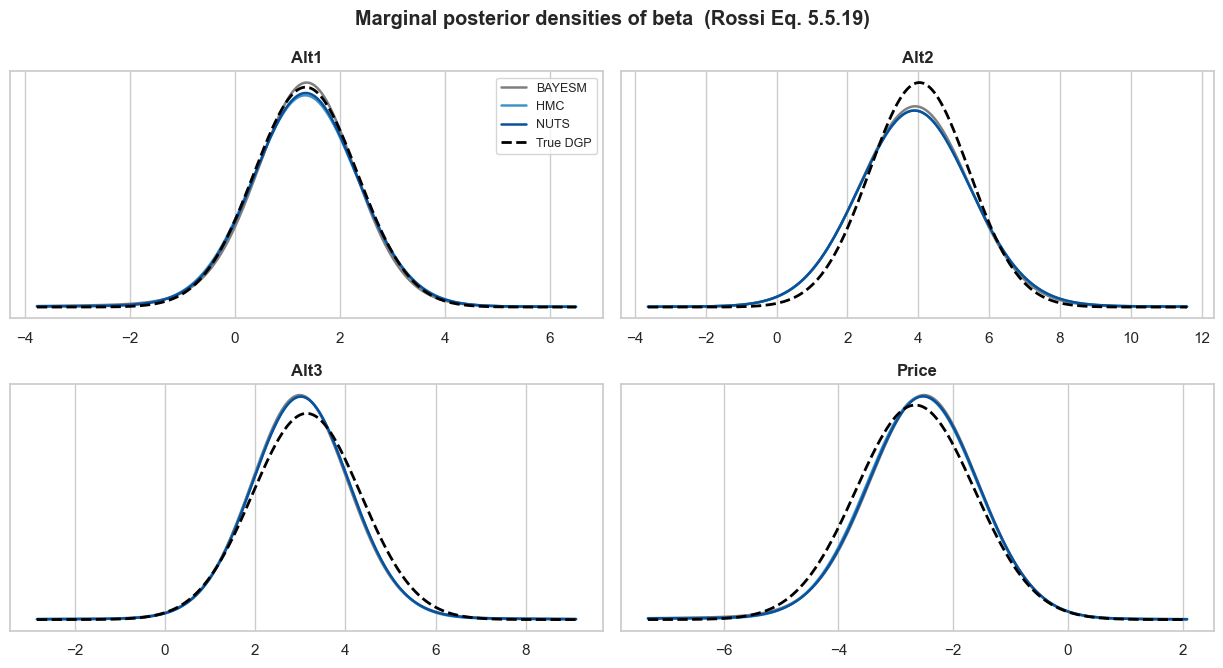

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler param                                                    
BAYESM  Alt1     0.05454  0.02306  0.00256  0.02195       0.03648
        Alt2     0.07539  0.03009  0.00543  0.06455       0.19616
        Alt3     0.06342  0.01921  0.00387  0.06085       0.14072
        Price    0.06289  0.01948  0.00379  0.06061       0.12536
HMC     Alt1     0.04235  0.01257  0.00159  0.01882       0.04437
        Alt2     0.08167  0.03599  0.00635  0.07149       0.20722
        Alt3     0.05967  0.01675  0.00343  0.05679       0.12892
        Price    0.05237  0.01238  0.00267  0.05182       0.11519
NUTS    Alt1     0.04485  0.01508  0.00175  0.01540       0.03860
        Alt2     0.08297  0.03752  0.00654  0.07217       0.20965
        Alt3     0.06005  0.01800  0.00344  0.05570       0.12114
        Price    0.05885  0.01646  0.00334  0.05753       0.12430

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,BAYESM,HMC,NUTS,True DGP
Alt1,1.296,1.269,1.298,1.349
Alt2,3.870,3.889,3.902,4.032
Alt3,2.994,2.980,3.007,3.141
Price,-2.576,-2.592,-2.590,-2.659


diag Var[theta]  (overall mixture variance):


,BAYESM,HMC,NUTS,True DGP
Alt1,1.652,7.058,7.388,0.980
Alt2,3.073,7.075,6.243,1.974
Alt3,1.906,4.036,3.356,1.454
Price,1.864,3.268,2.719,1.063


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- BAYESM ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,26,613.747,1119.526,1.008,1.003
Alt2,26,921.158,2326.036,1.003,1.001
Alt3,24,497.316,1527.249,1.004,1.002
Price,28,473.376,2472.364,1.008,1.003


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,235.138,324.420,1.033,1.017
Alt2,26,96.372,635.644,1.041,1.011
Alt3,23,182.338,313.399,1.028,1.020
Price,26,49.631,798.054,1.060,1.029


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,825.346,1530.519,1.006,1.004
Alt2,26,572.794,3004.313,1.002,1.001
Alt3,24,524.636,1695.113,1.004,1.002
Price,26,368.878,2754.274,1.010,1.005


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- BAYESM ---


ESS    Rhat
param moment                   
Alt1  Mean    2308.0089  1.0013
      Var     1962.8441  1.0015
Alt2  Mean    2074.3803  1.0011
      Var     2766.6972  1.0019
Alt3  Mean    1716.5048  1.0011
      Var     1850.8184  1.0019
Price Mean     856.5782  1.0054
      Var      782.0709  1.0064

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean    185.3584  1.0150
      Var     133.0762  1.0298
Alt2  Mean    176.9411  1.0287
      Var     215.9821  1.0211
Alt3  Mean    148.3917  1.0183
      Var     212.2865  1.0164
Price Mean    183.1279  1.0293
      Var      96.1808  1.0413

--- NUTS ---


ESS    Rhat
param moment                   
Alt1  Mean    2030.8994  1.0040
      Var     1019.5554  1.0031
Alt2  Mean    1476.2726  1.0010
      Var     2528.9901  1.0008
Alt3  Mean    1274.3598  1.0007
      Var     1837.8628  1.0041
Price Mean     681.0682  1.0060
      Var      674.2134  1.0085


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
